In [1]:


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:


import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_predict_50k.csv',
 'placement_dataset.csv',
 'placement_predict_50k Dataset (1).csv',
 'age_insurance.csv',
 '2520030358 _Experiment 4.ipynb',
 'placement_predict_50k_adjusted.csv',
 'Experiment5_2520030358.ipynb',
 'simple_placement_dataset.csv',
 'WineQT.csv',
 'Experiment_4_2520030358.ipynb',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'student_data.csv',
 'iris_dataset.csv',
 'breast_cancer_classification_dataset (1) (1).csv',
 'mall_customers_clustering_dataset.csv']

In [3]:

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

Dataset:
   CustomerID  Age  Annual_Income_k  Spending_Score
0           1   19               15              39
1           2   21               15              81
2           3   20               16               6
3           4   23               16              77
4           5   31               17              40

Dataset Shape:
(20, 4)


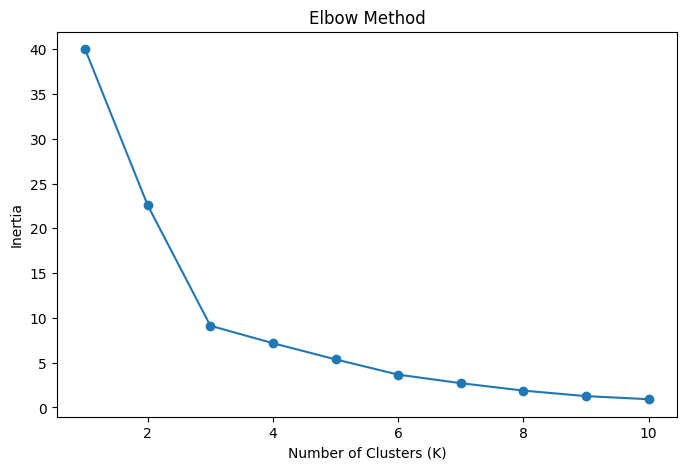


Clustered Dataset:
    CustomerID  Age  Annual_Income_k  Spending_Score  Cluster
0            1   19               15              39        0
1            2   21               15              81        2
2            3   20               16               6        3
3            4   23               16              77        2
4            5   31               17              40        0
5            6   22               17              76        2
6            7   35               18               6        3
7            8   23               18              94        2
8            9   64               19               3        3
9           10   30               20              72        2
10          11   67               20              14        3
11          12   35               21              99        2
12          13   58               23              15        3
13          14   24               23              77        2
14          15   37               24              

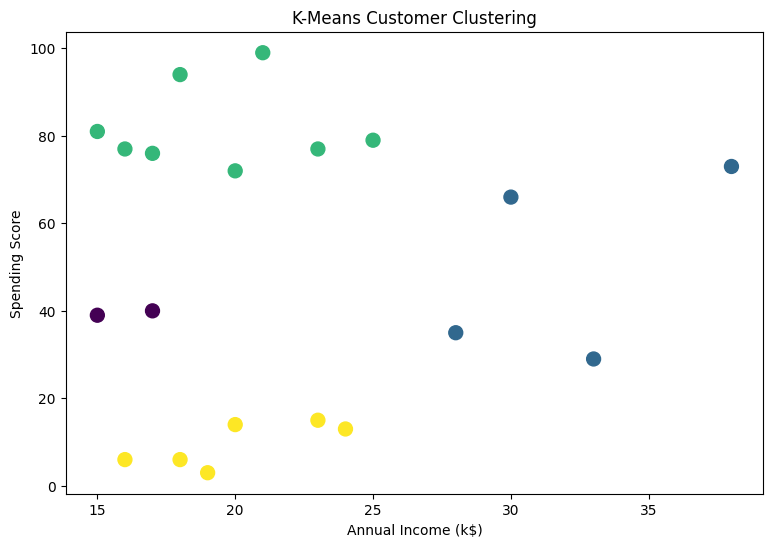


Clustered data saved as customer_clusters_output.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# ==========================================
# 1. LOAD DATASET
# ==========================================

data = pd.read_csv('/content/drive/MyDrive/Colab/mall_customers_clustering_dataset.csv')

print("Dataset:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)


# ==========================================
# 2. SELECT FEATURES
# ==========================================

X = data[["Annual_Income_k", "Spending_Score"]]


# ==========================================
# 3. SCALE THE DATA
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ==========================================
# 4. ELBOW METHOD
# ==========================================

inertia = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)


# Plot Elbow Curve

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()


# ==========================================
# 5. K-MEANS CLUSTERING
# ==========================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

data["Cluster"] = kmeans.fit_predict(X_scaled)


# ==========================================
# 6. DISPLAY RESULTS
# ==========================================

print("\nClustered Dataset:")
print(data)


# ==========================================
# 7. CLUSTER CENTERS
# ==========================================

print("\nCluster Centers:")

centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

print(centers)


# ==========================================
# 8. VISUALIZE CLUSTERS
# ==========================================

plt.figure(figsize=(9, 6))

plt.scatter(
    data["Annual_Income_k"],
    data["Spending_Score"],
    c=data["Cluster"],
    s=100
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.title("K-Means Customer Clustering")

plt.show()


# ==========================================
# 9. SAVE CLUSTERED DATA
# ==========================================

data.to_csv(
    "customer_clusters_output.csv",
    index=False
)

print("\nClustered data saved as customer_clusters_output.csv")